# Benchmark DVN depth-2 vs Greedy depth-2 vs Random (3P)
- **DVN depth-2** : $a^* = \arg\max_a \left[ r_0 + \gamma \max_{a'} \left[ r_1 + \gamma^2\, V(s'') \right] \right]$ — lookahead sur la pièce courante **et** la suivante dans le round, un seul forward pass batché
- **Greedy depth-2** : $a^* = \arg\max_a \left[ r_0 + \max_{a'} r_1 \right]$ — recherche exhaustive sur 2 pièces consécutives du round, sans réseau
- **Random** : action valide uniformément aléatoire

In [3]:
import sys
from pathlib import Path

src_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None)
if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory.")
sys.path.insert(0, str(src_path))
print(f"Root: {src_path}")

Root: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from src.blockblast.block_blast_3p_env import BlockBlast3PEnv
from src.dvn.agent import DVNAgent1P, RoundPlanner3P
from src.dvn.models import BlockBlastValueNet1PmultikernelFlattenned, BlockBlastValueNet1P

In [5]:
# ── Configuration ──────────────────────────────────────────────────
CHECKPOINT = src_path / 'final_weights' / 'dvn_final_20260313_020137.pt'
EPISODES   = 1000   # épisodes par politique
MAX_STEPS  = 500    # steps max par épisode
SEED       = 123
GAMMA      = 0.99
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device : {DEVICE}')
print(f'Checkpoint : {CHECKPOINT}')

Device : cuda
Checkpoint : /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/final_weights/dvn_final_20260313_020137.pt


In [6]:
# ── Chargement du modèle DVN ────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
policy_keys = set(checkpoint['policy_state_dict'].keys())
model_cls = BlockBlastValueNet1PmultikernelFlattenned if any(k.startswith('branches.') for k in policy_keys) else BlockBlastValueNet1P

agent = DVNAgent1P(policy_net=model_cls, device=DEVICE)
agent.policy_net.load_state_dict(checkpoint['policy_state_dict'])
agent.target_net.load_state_dict(checkpoint['target_state_dict'])
agent.policy_net.eval()
agent.target_net.eval()
print('Model loaded:', model_cls.__name__)

Model loaded: BlockBlastValueNet1PmultikernelFlattenned


In [10]:
# ── Helpers ─────────────────────────────────────────────────────────

def dvn_depth2_action(env, agent, gamma):
    """
    a* = argmax_a [ r0 + gamma * max_a' [ r1 + gamma^2 * V(s'') ] ]

    - Si la pièce placée est la dernière du round (pas de suite connue),
      on replie sur depth-1 :  r0 + gamma * V(s').
    - Tous les boards terminaux sont évalués en un seul forward pass batché.
    """
    g     = env.grid_size
    n     = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_mask    = env.valid_placements.reshape(-1)
    valid_actions = np.flatnonzero(valid_mask)
    if valid_actions.size == 0:
        return None

    eval_boards: list[np.ndarray] = []
    r0_per_l0:   list[float]      = []
    meta: list = []

    for action in valid_actions:
        piece_idx = int(action // (g * g))
        pos       = int(action %  (g * g))
        row, col  = divmod(pos, g)

        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, piece_idx, row, col)
        r0_per_l0.append(r0)

        pieces_used1 = env.pieces_used.copy()
        pieces_used1[piece_idx] = 1
        remaining = [i for i in range(n) if not pieces_used1[i]]

        if not remaining:
            idx = len(eval_boards)
            eval_boards.append(board1.astype(np.float32))
            meta.append(('d1', idx))
        else:
            start = len(eval_boards)
            l1_rewards: list[float] = []
            for p1 in remaining:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    board2, r1, _ = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)
                    eval_boards.append(board2.astype(np.float32))
                    l1_rewards.append(r1)
            count = len(eval_boards) - start
            if count == 0:
                idx = len(eval_boards)
                eval_boards.append(board1.astype(np.float32))
                meta.append(('d1', idx))
            else:
                meta.append(('d2', start, count, np.array(l1_rewards, dtype=np.float32)))

    if not eval_boards:
        return int(valid_actions[0])

    boards_np = np.array(eval_boards, dtype=np.float32)
    boards_t  = torch.from_numpy(boards_np).to(agent.device)
    with torch.inference_mode():
        v_all = agent.policy_net(boards_t).squeeze(-1).cpu().numpy()

    q0 = np.empty(len(valid_actions), dtype=np.float32)
    for i, m in enumerate(meta):
        r0 = r0_per_l0[i]
        if m[0] == 'd1':
            q0[i] = r0 + gamma * float(v_all[m[1]])
        else:  # 'd2'
            _, start, count, r1_arr = m
            q1 = r1_arr + gamma * v_all[start:start + count]
            q0[i] = r0 + gamma * float(np.max(q1))

    return int(valid_actions[np.argmax(q0)])


def greedy_depth2_action(env):
    """
    a* = argmax_{a0} [ r0 + max_{a1} r1 ]

    Recherche exhaustive sur la pièce courante + la pièce suivante du round,
    sans réseau. Fallback sur depth-1 si la pièce courante est la dernière du round.
    """
    g      = env.grid_size
    n      = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_mask    = env.valid_placements.reshape(-1)
    valid_actions = np.flatnonzero(valid_mask)
    if valid_actions.size == 0:
        return None

    best_total, best_a = -np.inf, valid_actions[0]

    for action in valid_actions:
        piece_idx = int(action // (g * g))
        row, col  = divmod(int(action % (g * g)), g)

        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, piece_idx, row, col)
        pieces_used1 = env.pieces_used.copy()
        pieces_used1[piece_idx] = 1
        remaining1 = [i for i in range(n) if not pieces_used1[i]]

        if not remaining1:
            total = r0
        else:
            best_r1 = -np.inf
            for p1 in remaining1:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    _, r1, _ = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)
                    if r1 > best_r1:
                        best_r1 = r1
            total = r0 + (best_r1 if best_r1 > -np.inf else 0.0)

        if total > best_total:
            best_total, best_a = total, action

    return int(best_a)


def random_action(env, rng):
    valid = np.flatnonzero(env.valid_placements.reshape(-1).astype(bool))
    return int(rng.choice(valid)) if valid.size > 0 else None

In [33]:
# ── Eval DVN depth-2 ────────────────────────────────────────────────
env_dvn = BlockBlast3PEnv(lookahead_gamma=GAMMA)

dvn_returns, dvn_lengths = [], []
for ep in tqdm(range(EPISODES), desc='DVN depth-2'):
    env_dvn.reset(seed=SEED + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = dvn_depth2_action(env_dvn, agent, GAMMA)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_dvn.step(action)
        total += r
        if terminated or truncated:
            break
    dvn_returns.append(total)
    dvn_lengths.append(step + 1)

dvn_returns = np.array(dvn_returns)
dvn_lengths = np.array(dvn_lengths)
print(f'DVN depth-2 — reward  mean={dvn_returns.mean():.2f}  std={dvn_returns.std():.2f}  median={np.median(dvn_returns):.2f}  max={dvn_returns.max():.2f}')
print(f'DVN depth-2 — length  mean={dvn_lengths.mean():.2f}  median={np.median(dvn_lengths):.2f}')

DVN depth-2:   0%|          | 0/1000 [00:00<?, ?it/s]

DVN depth-2 — reward  mean=22419.30  std=24563.20  median=13148.75  max=153056.60
DVN depth-2 — length  mean=201.79  median=162.00


In [47]:
# ── Eval Greedy depth-2 ─────────────────────────────────────────────
env_g2 = BlockBlast3PEnv(lookahead_gamma=GAMMA)

g2_returns, g2_lengths = [], []
for ep in tqdm(range(EPISODES), desc='Greedy depth-2'):
    env_g2.reset(seed=SEED + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = greedy_depth2_action(env_g2)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_g2.step(action)
        total += r
        if terminated or truncated:
            break
    g2_returns.append(total)
    g2_lengths.append(step + 1)

g2_returns = np.array(g2_returns)
g2_lengths = np.array(g2_lengths)
print(f'Greedy depth-2 — reward  mean={g2_returns.mean():.2f}  std={g2_returns.std():.2f}  median={np.median(g2_returns):.2f}  max={g2_returns.max():.2f}')
print(f'Greedy depth-2 — length  mean={g2_lengths.mean():.2f}  median={np.median(g2_lengths):.2f}')

Greedy depth-2:   0%|          | 0/1000 [00:00<?, ?it/s]

Greedy depth-2 — reward  mean=1908.75  std=2570.02  median=1133.10  max=34280.20
Greedy depth-2 — length  mean=45.91  median=41.00


In [48]:
# ── Eval Random ─────────────────────────────────────────────────────
env_rnd = BlockBlast3PEnv(lookahead_gamma=GAMMA)
rng = np.random.default_rng(seed=SEED)

rnd_returns, rnd_lengths = [], []
for ep in tqdm(range(EPISODES), desc='Random'):
    env_rnd.reset(seed=SEED + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = random_action(env_rnd, rng)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_rnd.step(action)
        total += r
        if terminated or truncated:
            break
    rnd_returns.append(total)
    rnd_lengths.append(step + 1)

rnd_returns = np.array(rnd_returns)
rnd_lengths = np.array(rnd_lengths)
print(f'Random — reward  mean={rnd_returns.mean():.2f}  std={rnd_returns.std():.2f}  median={np.median(rnd_returns):.2f}  max={rnd_returns.max():.2f}')
print(f'Random — length  mean={rnd_lengths.mean():.2f}  median={np.median(rnd_lengths):.2f}')

Random:   0%|          | 0/1000 [00:00<?, ?it/s]

Random — reward  mean=22.84  std=47.74  median=10.70  max=622.70
Random — length  mean=11.78  median=11.00


Plot saved to /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_depth2_20260314_225859.png
N episodes: DVN=1000, Greedy=1000, Random=1000
Reward display cap: 20000


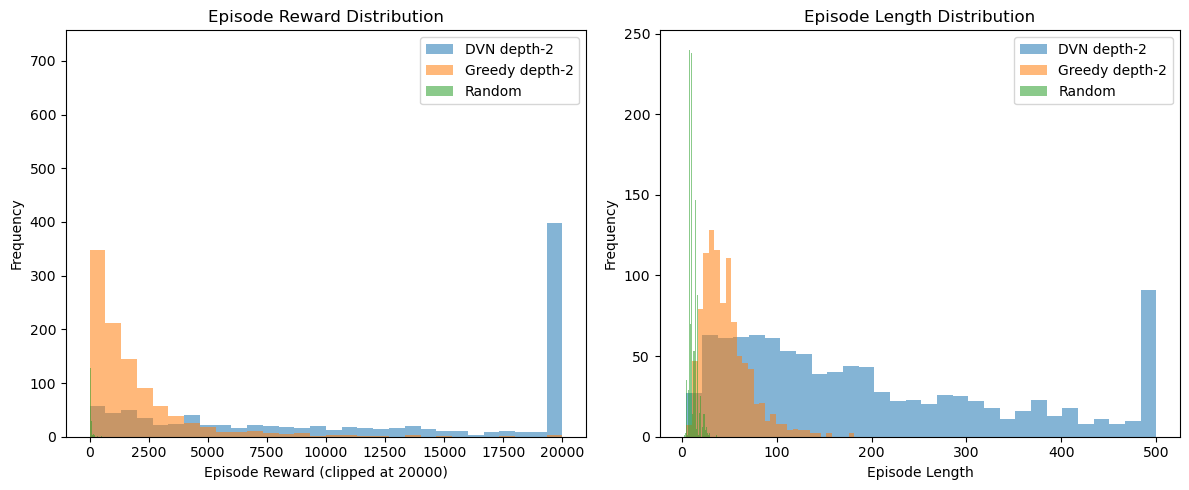

In [49]:
# ── Plots ────────────────────────────────────────────────────────────
%matplotlib inline

reward_display_cap = 20000

dvn_returns_plot = np.clip(dvn_returns, 0, reward_display_cap)
g2_returns_plot = np.clip(g2_returns, 0, reward_display_cap)
rnd_returns_plot = np.clip(rnd_returns, 0, reward_display_cap)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(dvn_returns_plot, bins=30, alpha=0.55, label='DVN depth-2')
plt.hist(g2_returns_plot, bins=30, alpha=0.55, label='Greedy depth-2')
plt.hist(rnd_returns_plot, bins=30, alpha=0.55, label='Random')
plt.title('Episode Reward Distribution')
plt.xlabel(f'Episode Reward (clipped at {reward_display_cap})')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(dvn_lengths, bins=30, alpha=0.55, label='DVN depth-2')
plt.hist(g2_lengths, bins=30, alpha=0.55, label='Greedy depth-2')
plt.hist(rnd_lengths, bins=30, alpha=0.55, label='Random')
plt.title('Episode Length Distribution')
plt.xlabel('Episode Length')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()

out_dir = src_path / 'plots'
out_dir.mkdir(exist_ok=True)
from datetime import datetime
fig_path = out_dir / f"benchmark_3p_depth2_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_path, dpi=150)
print(f'Plot saved to {fig_path}')
print(f'N episodes: DVN={len(dvn_returns)}, Greedy={len(g2_returns)}, Random={len(rnd_returns)}')
print(f'Reward display cap: {reward_display_cap}')
plt.show()

Alternative plot saved to /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_depth2_alt_20260314_225909.png


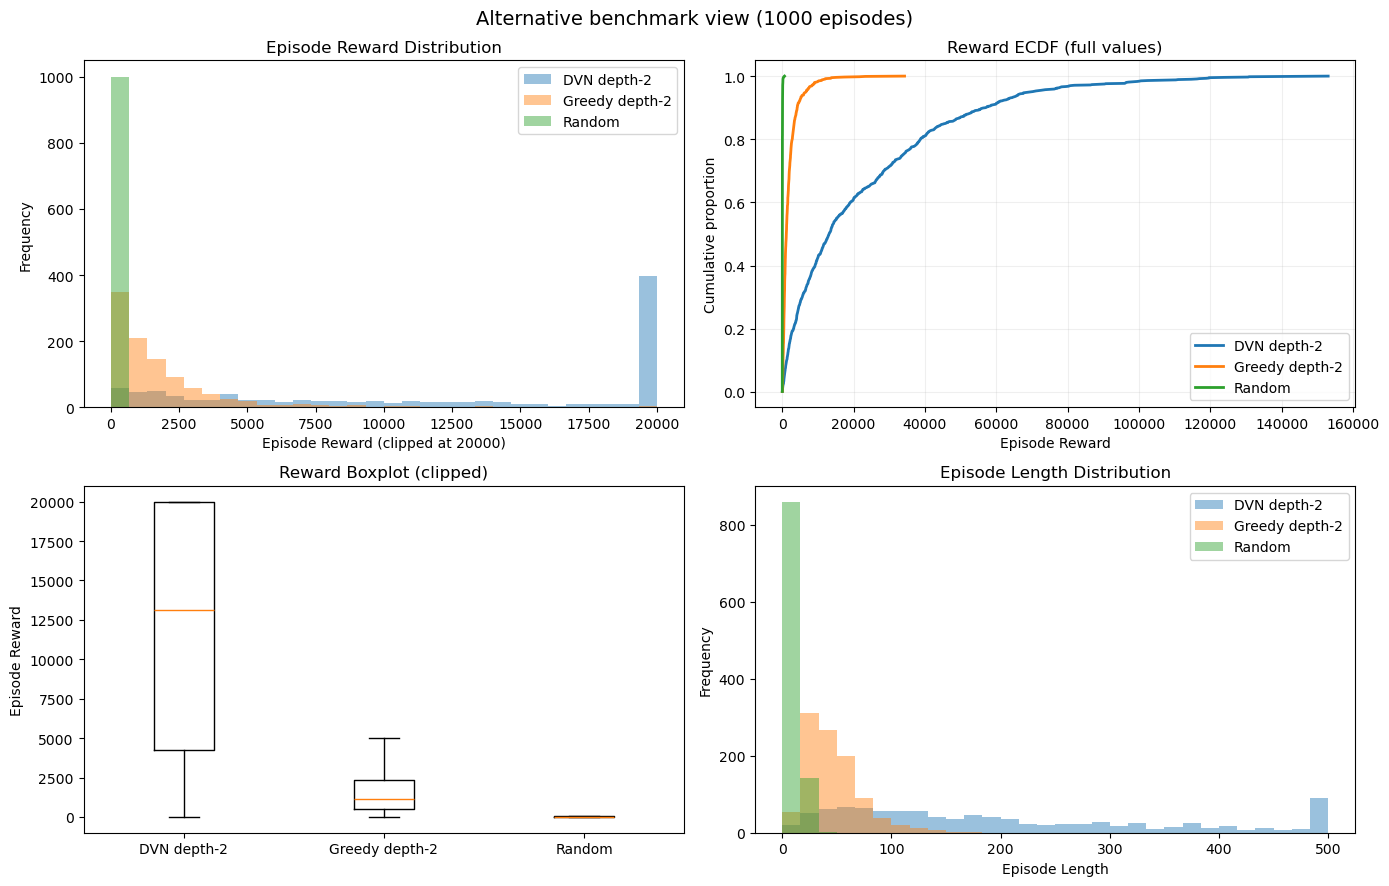

In [50]:
# ── Alternative view ────────────────────────────────────────────────
%matplotlib inline

reward_display_cap = 20000


def ecdf(values):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


dvn_returns_plot = np.clip(dvn_returns, 0, reward_display_cap)
g2_returns_plot = np.clip(g2_returns, 0, reward_display_cap)
rnd_returns_plot = np.clip(rnd_returns, 0, reward_display_cap)

reward_bins = np.linspace(0, reward_display_cap, 31)
length_max = max(np.max(dvn_lengths), np.max(g2_lengths), np.max(rnd_lengths))
length_bins = np.linspace(0, length_max, 31)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.hist(dvn_returns_plot, bins=reward_bins, alpha=0.45, label='DVN depth-2')
ax.hist(g2_returns_plot, bins=reward_bins, alpha=0.45, label='Greedy depth-2')
ax.hist(rnd_returns_plot, bins=reward_bins, alpha=0.45, label='Random')
ax.set_title('Episode Reward Distribution')
ax.set_xlabel(f'Episode Reward (clipped at {reward_display_cap})')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[0, 1]
for values, label in [
    (dvn_returns, 'DVN depth-2'),
    (g2_returns, 'Greedy depth-2'),
    (rnd_returns, 'Random'),
]:
    x, y = ecdf(values)
    ax.plot(x, y, linewidth=2, label=label)
ax.set_title('Reward ECDF (full values)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Cumulative proportion')
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1, 0]
ax.boxplot(
    [dvn_returns_plot, g2_returns_plot, rnd_returns_plot],
    tick_labels=['DVN depth-2', 'Greedy depth-2', 'Random'],
    showfliers=False,
)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Episode Reward')

ax = axes[1, 1]
ax.hist(dvn_lengths, bins=length_bins, alpha=0.45, label='DVN depth-2')
ax.hist(g2_lengths, bins=length_bins, alpha=0.45, label='Greedy depth-2')
ax.hist(rnd_lengths, bins=length_bins, alpha=0.45, label='Random')
ax.set_title('Episode Length Distribution')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Frequency')
ax.legend()

plt.suptitle(f'Alternative benchmark view ({EPISODES} episodes)', fontsize=14)
plt.tight_layout()

out_dir = src_path / 'plots'
out_dir.mkdir(exist_ok=True)
from datetime import datetime
fig_path_alt = out_dir / f"benchmark_3p_depth2_alt_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_path_alt, dpi=150)
print(f'Alternative plot saved to {fig_path_alt}')
plt.show()

## Bonus: Mini benchmark 3P sur `BONUS_EPISODES` épisodes (`DVN + MCTS` vs `Greedy depth-3` vs `Random`)

Cette section **s'ajoute** au benchmark principal.

- `DVN + MCTS` = recherche arborescente budgetée par le DVN entraîné, calibrée pour une capacité proche d'un lookahead depth-2.
- `Greedy depth-3` = recherche exhaustive sur 3 coups avec récompenses immédiates.
- `Random` = action valide uniforme.

In [33]:
import math

# ── Bonus helpers (DVN + MCTS / Greedy depth-3) ───────────────────
BONUS_EPISODES = 30
DVN_MCTS_BATCH_SIZE = 256
MCTS_SIMULATIONS = 24
MCTS_MAX_CHILDREN = 10
MCTS_UCB_C = 1.4


def _dvn_value_batch(agent, boards, batch_size=256):
    if len(boards) == 0:
        return np.array([], dtype=np.float32)

    boards_np = np.asarray(boards, dtype=np.float32)
    values = []
    for start in range(0, len(boards_np), batch_size):
        chunk = torch.from_numpy(boards_np[start:start + batch_size]).to(agent.device)
        with torch.inference_mode():
            values.append(agent.policy_net(chunk).squeeze(-1).cpu().numpy())
    return np.concatenate(values).astype(np.float32, copy=False)


def _dvn_depth1_action(env, agent, gamma=0.99):
    valid_actions = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions.size == 0:
        return None

    g = env.grid_size
    boards = []
    rewards = []
    for action in valid_actions.tolist():
        piece_idx = int(action // (g * g))
        row, col = divmod(int(action % (g * g)), g)
        next_board, reward, _ = env._simulate_one_hyp_step(env.board, int(env.combo), piece_idx, row, col)
        boards.append(next_board)
        rewards.append(float(reward))

    values = _dvn_value_batch(agent, boards, batch_size=DVN_MCTS_BATCH_SIZE)
    q = np.asarray(rewards, dtype=np.float32) + gamma * values
    return int(valid_actions[int(np.argmax(q))])


def _enumerate_mcts_actions(env, board, combo, pieces_used):
    out = []
    g = env.grid_size
    board = np.asarray(board, dtype=np.int8)
    pieces_used = np.asarray(pieces_used, dtype=np.int8)
    for piece_idx in range(env.n_pieces):
        if pieces_used[piece_idx]:
            continue
        valid = env._valid_positions_for_piece_on_board(board, piece_idx)
        rows, cols = np.nonzero(valid)
        for row, col in zip(rows.tolist(), cols.tolist()):
            next_board, reward, next_combo = env._simulate_one_hyp_step(board, combo, piece_idx, row, col)
            next_used = pieces_used.copy()
            next_used[piece_idx] = 1
            action = int(piece_idx * g * g + row * g + col)
            out.append((action, next_board.astype(np.int8, copy=False), float(reward), int(next_combo), next_used))
    return out


class _MCTSNode:
    __slots__ = (
        'board', 'combo', 'pieces_used', 'depth', 'parent', 'action_from_parent',
        'reward_from_parent', 'children', 'untried', 'is_expanded', 'visit_count', 'value_sum'
    )

    def __init__(self, board, combo, pieces_used, depth=0, parent=None, action_from_parent=None, reward_from_parent=0.0):
        self.board = np.asarray(board, dtype=np.int8)
        self.combo = int(combo)
        self.pieces_used = np.asarray(pieces_used, dtype=np.int8).copy()
        self.depth = int(depth)
        self.parent = parent
        self.action_from_parent = action_from_parent
        self.reward_from_parent = float(reward_from_parent)
        self.children = {}
        self.untried = []
        self.is_expanded = False
        self.visit_count = 0
        self.value_sum = 0.0

    def mean_value(self):
        return self.value_sum / self.visit_count if self.visit_count > 0 else 0.0


class DVNMCTSPlanner:
    def __init__(self, agent, gamma=0.99, simulations=24, ucb_c=1.4, max_children=10, eval_batch_size=256):
        self.agent = agent
        self.gamma = float(gamma)
        self.simulations = int(simulations)
        self.ucb_c = float(ucb_c)
        self.max_children = int(max_children)
        self.eval_batch_size = int(eval_batch_size)

    def _rank_actions(self, env, board, combo, pieces_used):
        candidates = _enumerate_mcts_actions(env, board, combo, pieces_used)
        if not candidates:
            return []

        boards = [cand[1] for cand in candidates]
        rewards = np.array([cand[2] for cand in candidates], dtype=np.float32)
        values = _dvn_value_batch(self.agent, boards, batch_size=self.eval_batch_size)
        scores = rewards + self.gamma * values
        order = np.argsort(-scores)
        if self.max_children > 0:
            order = order[:self.max_children]
        return [candidates[int(i)] for i in order]

    def _ensure_expanded(self, env, node):
        if node.is_expanded:
            return
        node.untried = self._rank_actions(env, node.board, node.combo, node.pieces_used)
        node.is_expanded = True

    def _select_child(self, node):
        log_parent = math.log(max(1, node.visit_count))
        best_score = -np.inf
        best_child = None
        for child in node.children.values():
            exploit = child.mean_value()
            explore = self.ucb_c * math.sqrt(log_parent / child.visit_count) if child.visit_count > 0 else np.inf
            score = exploit + explore
            if score > best_score:
                best_score = score
                best_child = child
        return best_child

    def _leaf_bootstrap(self, node, has_actions):
        if not has_actions:
            return 0.0
        value = _dvn_value_batch(self.agent, [node.board], batch_size=1)
        return float(value[0])

    def _search_round_start(self, env):
        root = _MCTSNode(env.board.copy(), int(env.combo), env.pieces_used.copy(), depth=0)
        max_depth = int(np.sum(1 - env.pieces_used))
        if max_depth <= 0:
            return None

        self._ensure_expanded(env, root)
        if not root.untried:
            return None

        for _ in range(self.simulations):
            node = root
            path = [root]

            while True:
                is_round_leaf = node.depth >= max_depth or bool(np.all(node.pieces_used))
                if is_round_leaf:
                    break

                self._ensure_expanded(env, node)
                if node.untried:
                    action, next_board, reward, next_combo, next_used = node.untried.pop(0)
                    child = _MCTSNode(
                        board=next_board,
                        combo=next_combo,
                        pieces_used=next_used,
                        depth=node.depth + 1,
                        parent=node,
                        action_from_parent=action,
                        reward_from_parent=reward,
                    )
                    node.children[action] = child
                    node = child
                    path.append(node)
                    break

                if not node.children:
                    break

                node = self._select_child(node)
                path.append(node)

            is_round_leaf = node.depth >= max_depth or bool(np.all(node.pieces_used))
            if is_round_leaf:
                leaf_value = self._leaf_bootstrap(node, has_actions=True)
            else:
                self._ensure_expanded(env, node)
                leaf_value = self._leaf_bootstrap(node, has_actions=bool(node.untried or node.children))

            ret = leaf_value
            path[-1].visit_count += 1
            path[-1].value_sum += ret

            for idx in range(len(path) - 2, -1, -1):
                child = path[idx + 1]
                ret = child.reward_from_parent + self.gamma * ret
                path[idx].visit_count += 1
                path[idx].value_sum += ret

        best_child = max(root.children.values(), key=lambda child: (child.visit_count, child.mean_value()))
        return int(best_child.action_from_parent)

    def select_action(self, env):
        if np.any(env.pieces_used):
            return _dvn_depth1_action(env, self.agent, gamma=self.gamma)
        return self._search_round_start(env)


def greedy_depth3_action_bonus(env):
    """a* = argmax_a0 [ r0 + max_a1 [ r1 + max_a2 r2 ] ], exhaustive on 3 levels."""
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions0 = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions0.size == 0:
        return None

    best_total, best_action = -np.inf, int(valid_actions0[0])

    for a0 in valid_actions0:
        p0 = int(a0 // (g * g))
        r0_idx = int(a0 % (g * g))
        row0, col0 = divmod(r0_idx, g)

        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, p0, row0, col0)
        used1 = env.pieces_used.copy()
        used1[p0] = 1
        rem1 = [i for i in range(n) if not used1[i]]

        if not rem1:
            total0 = float(r0)
        else:
            best_l1 = -np.inf
            for p1 in rem1:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    board2, r1, combo2 = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)

                    used2 = used1.copy()
                    used2[p1] = 1
                    rem2 = [i for i in range(n) if not used2[i]]

                    if not rem2:
                        score1 = float(r1)
                    else:
                        best_l2 = -np.inf
                        for p2 in rem2:
                            valid2 = env._valid_positions_for_piece_on_board(board2, p2)
                            rows2, cols2 = np.nonzero(valid2)
                            for r2v, c2v in zip(rows2.tolist(), cols2.tolist()):
                                _, r2, _ = env._simulate_one_hyp_step(board2, combo2, p2, r2v, c2v)
                                if r2 > best_l2:
                                    best_l2 = r2
                        score1 = float(r1) + (best_l2 if best_l2 > -np.inf else 0.0)

                    if score1 > best_l1:
                        best_l1 = score1

            total0 = float(r0) + (best_l1 if best_l1 > -np.inf else 0.0)

        if total0 > best_total:
            best_total, best_action = total0, int(a0)

    return best_action

In [34]:
# ── MCTS calibration: capacity proche depth-2 ───────────────────────
MCTS_SEARCH_DEPTH = 2
MCTS_SIMULATIONS = 16
MCTS_MAX_CHILDREN = 10


class DVNMCTSPlanner(DVNMCTSPlanner):
    def __init__(
        self,
        agent,
        gamma=0.99,
        simulations=MCTS_SIMULATIONS,
        ucb_c=MCTS_UCB_C,
        max_children=MCTS_MAX_CHILDREN,
        eval_batch_size=DVN_MCTS_BATCH_SIZE,
        search_depth=MCTS_SEARCH_DEPTH,
    ):
        super().__init__(
            agent=agent,
            gamma=gamma,
            simulations=simulations,
            ucb_c=ucb_c,
            max_children=max_children,
            eval_batch_size=eval_batch_size,
        )
        self.search_depth = int(search_depth)

    def _search_round_start(self, env):
        root = _MCTSNode(env.board.copy(), int(env.combo), env.pieces_used.copy(), depth=0)
        remaining_depth = int(np.sum(1 - env.pieces_used))
        max_depth = min(remaining_depth, self.search_depth)
        if max_depth <= 0:
            return None

        self._ensure_expanded(env, root)
        if not root.untried:
            return None

        for _ in range(self.simulations):
            node = root
            path = [root]

            while True:
                is_search_leaf = node.depth >= max_depth
                is_round_leaf = bool(np.all(node.pieces_used))
                if is_search_leaf or is_round_leaf:
                    break

                self._ensure_expanded(env, node)
                if node.untried:
                    action, next_board, reward, next_combo, next_used = node.untried.pop(0)
                    child = _MCTSNode(
                        board=next_board,
                        combo=next_combo,
                        pieces_used=next_used,
                        depth=node.depth + 1,
                        parent=node,
                        action_from_parent=action,
                        reward_from_parent=reward,
                    )
                    node.children[action] = child
                    node = child
                    path.append(node)
                    break

                if not node.children:
                    break

                node = self._select_child(node)
                path.append(node)

            self._ensure_expanded(env, node)
            leaf_value = self._leaf_bootstrap(node, has_actions=bool(node.untried or node.children))

            ret = leaf_value
            path[-1].visit_count += 1
            path[-1].value_sum += ret

            for idx in range(len(path) - 2, -1, -1):
                child = path[idx + 1]
                ret = child.reward_from_parent + self.gamma * ret
                path[idx].visit_count += 1
                path[idx].value_sum += ret

        best_child = max(root.children.values(), key=lambda child: (child.visit_count, child.mean_value()))
        return int(best_child.action_from_parent)

    def select_action(self, env):
        # Debut de round: MCTS budgete depth-2
        if not np.any(env.pieces_used):
            return self._search_round_start(env)
        # Milieu de round: fallback DVN depth-2 pour garder une capacite comparable
        return dvn_depth2_action(env, self.agent, self.gamma)

In [35]:
# ── Mini eval: DVN + MCTS ───────────────────────────────────────────
rng_small = np.random.default_rng(seed=SEED + 999)

mcts_planner = DVNMCTSPlanner(
    agent=agent,
    gamma=GAMMA,
    simulations=MCTS_SIMULATIONS,
    ucb_c=MCTS_UCB_C,
    max_children=MCTS_MAX_CHILDREN,
    eval_batch_size=DVN_MCTS_BATCH_SIZE,
)

env_mcts = BlockBlast3PEnv(lookahead_gamma=GAMMA)
mcts_returns, mcts_lengths = [], []
for ep in tqdm(range(BONUS_EPISODES), desc=f'DVN + MCTS ({BONUS_EPISODES} eps)'):
    env_mcts.reset(seed=SEED + 10_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = mcts_planner.select_action(env_mcts)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_mcts.step(action)
        total += r
        if terminated or truncated:
            break
    mcts_returns.append(total)
    mcts_lengths.append(step + 1)

mcts_returns = np.array(mcts_returns, dtype=np.float32)
mcts_lengths = np.array(mcts_lengths, dtype=np.int32)
print(f"DVN + MCTS    (n={len(mcts_returns)}) mean_reward={mcts_returns.mean():.2f} mean_len={mcts_lengths.mean():.2f}")

DVN + MCTS (30 eps):   0%|          | 0/30 [00:00<?, ?it/s]

DVN + MCTS    (n=30) mean_reward=18850.53 mean_len=169.70


In [36]:
# ── Mini eval: Greedy depth-3 / Random ──────────────────────────────
# Greedy depth-3
env_g3_small = BlockBlast3PEnv(lookahead_gamma=GAMMA)
g3_small_returns, g3_small_lengths = [], []
for ep in tqdm(range(BONUS_EPISODES), desc=f'Greedy depth-3 ({BONUS_EPISODES} eps)'):
    env_g3_small.reset(seed=SEED + 20_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = greedy_depth3_action_bonus(env_g3_small)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_g3_small.step(action)
        total += r
        if terminated or truncated:
            break
    g3_small_returns.append(total)
    g3_small_lengths.append(step + 1)

g3_small_returns = np.array(g3_small_returns, dtype=np.float32)
g3_small_lengths = np.array(g3_small_lengths, dtype=np.int32)
print(f"Greedy depth-3 (n={len(g3_small_returns)}) mean_reward={g3_small_returns.mean():.2f} mean_len={g3_small_lengths.mean():.2f}")

# Random
env_rnd_small = BlockBlast3PEnv(lookahead_gamma=GAMMA)
rnd_small_returns, rnd_small_lengths = [], []
for ep in tqdm(range(BONUS_EPISODES), desc=f'Random ({BONUS_EPISODES} eps)'):
    env_rnd_small.reset(seed=SEED + 30_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = random_action(env_rnd_small, rng_small)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_rnd_small.step(action)
        total += r
        if terminated or truncated:
            break
    rnd_small_returns.append(total)
    rnd_small_lengths.append(step + 1)

rnd_small_returns = np.array(rnd_small_returns, dtype=np.float32)
rnd_small_lengths = np.array(rnd_small_lengths, dtype=np.int32)
print(f"Random         (n={len(rnd_small_returns)}) mean_reward={rnd_small_returns.mean():.2f} mean_len={rnd_small_lengths.mean():.2f}")

print('\nRaw rewards:')
print('DVN + MCTS    :', mcts_returns.tolist())
print('Greedy depth-3:', g3_small_returns.tolist())
print('Random        :', rnd_small_returns.tolist())

Greedy depth-3 (30 eps):   0%|          | 0/30 [00:00<?, ?it/s]

Greedy depth-3 (n=30) mean_reward=2885.52 mean_len=48.37


Random (30 eps):   0%|          | 0/30 [00:00<?, ?it/s]

Random         (n=30) mean_reward=20.45 mean_len=12.17

Raw rewards:
DVN + MCTS    : [4054.699951171875, 13728.599609375, 892.2999877929688, 33962.8984375, 861.7000122070312, 6827.2001953125, 36742.3984375, 38312.6015625, 1373.5, 11579.599609375, 29762.400390625, 2415.0, 51620.3984375, 721.5999755859375, 69997.703125, 9388.5, 35138.30078125, 34732.80078125, 7336.0, 9135.2998046875, 2473.5, 672.4000244140625, 1422.4000244140625, 56613.6015625, 3663.199951171875, 10828.7001953125, 25340.099609375, 6485.7001953125, 57038.1015625, 2394.60009765625]
Greedy depth-3: [922.0, 732.5, 311.5, 6084.2998046875, 322.1000061035156, 12799.2001953125, 10408.0, 311.0, 2313.0, 741.7999877929688, 9615.099609375, 1832.300048828125, 2022.0, 40.70000076293945, 3783.89990234375, 2012.800048828125, 6153.89990234375, 371.29998779296875, 912.2000122070312, 361.20001220703125, 561.4000244140625, 11706.2001953125, 291.5, 1131.800048828125, 2112.5, 220.89999389648438, 251.39999389648438, 741.5, 6405.2001953125, 109

In [37]:
# ── Summary table ───────────────────────────────────────────────────
summary_rows = [
    ('DVN + MCTS', mcts_returns, mcts_lengths),
    ('Greedy depth-3', g3_small_returns, g3_small_lengths),
    ('Random', rnd_small_returns, rnd_small_lengths),
]

for name, returns, lengths in summary_rows:
    print(
        f"{name:16s} | reward mean={np.mean(returns):8.2f} std={np.std(returns):8.2f} "
        f"| len mean={np.mean(lengths):6.2f}"
    )

print(f'\nMCTS simulations per decision: {MCTS_SIMULATIONS}')
print(f'MCTS candidate cap per node : {MCTS_MAX_CHILDREN}')
print(f'MCTS search depth cap       : {MCTS_SEARCH_DEPTH}')
print('Mid-round fallback          : dvn_depth2_action')

DVN + MCTS       | reward mean=18850.53 std=20092.06 | len mean=169.70
Greedy depth-3   | reward mean= 2885.52 std= 3698.02 | len mean= 48.37
Random           | reward mean=   20.45 std=   33.11 | len mean= 12.17

MCTS simulations per decision: 16
MCTS candidate cap per node : 10
MCTS search depth cap       : 2
Mid-round fallback          : dvn_depth2_action


Bonus plot saved to /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_bonus_mcts_vs_greedy_random_20260315_125150.png


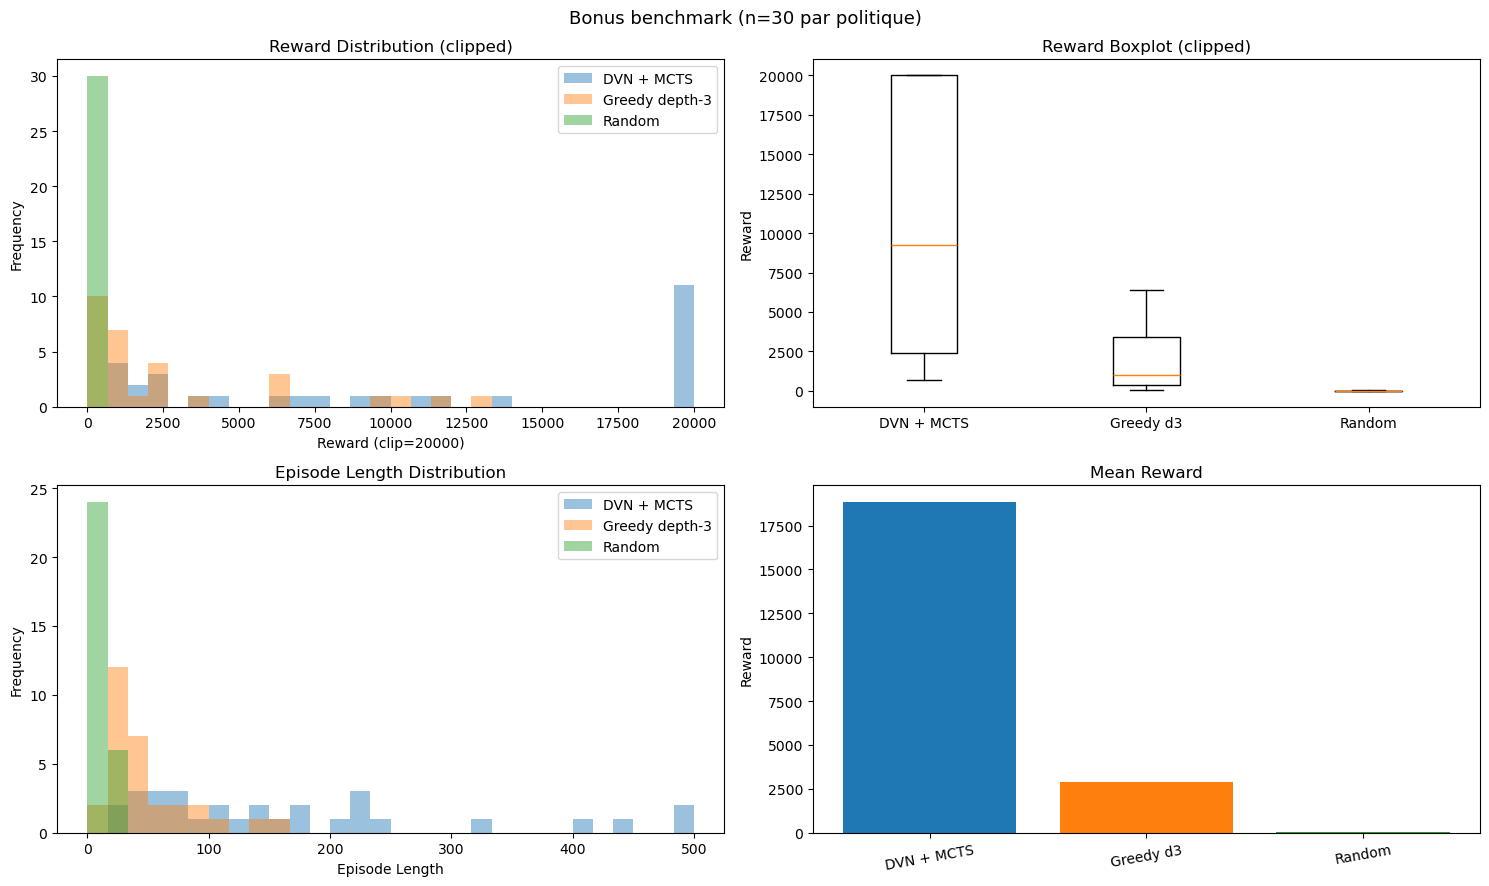

In [38]:
# ── Visualisation bonus ───────────────────────────────────────────────
%matplotlib inline

bonus_cap = 20000

mcts_plot = np.clip(mcts_returns, 0, bonus_cap)
g3_plot = np.clip(g3_small_returns, 0, bonus_cap)
rnd_plot = np.clip(rnd_small_returns, 0, bonus_cap)

reward_bins = np.linspace(0, bonus_cap, 31)
len_max = max(
    np.max(mcts_lengths),
    np.max(g3_small_lengths),
    np.max(rnd_small_lengths),
)
length_bins = np.linspace(0, len_max, 31)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
ax.hist(mcts_plot, bins=reward_bins, alpha=0.45, label='DVN + MCTS')
ax.hist(g3_plot, bins=reward_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd_plot, bins=reward_bins, alpha=0.45, label='Random')
ax.set_title('Reward Distribution (clipped)')
ax.set_xlabel(f'Reward (clip={bonus_cap})')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[0, 1]
ax.boxplot(
    [mcts_plot, g3_plot, rnd_plot],
    tick_labels=['DVN + MCTS', 'Greedy d3', 'Random'],
    showfliers=False,
)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Reward')

ax = axes[1, 0]
ax.hist(mcts_lengths, bins=length_bins, alpha=0.45, label='DVN + MCTS')
ax.hist(g3_small_lengths, bins=length_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd_small_lengths, bins=length_bins, alpha=0.45, label='Random')
ax.set_title('Episode Length Distribution')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1, 1]
means = [
    float(np.mean(mcts_returns)),
    float(np.mean(g3_small_returns)),
    float(np.mean(rnd_small_returns)),
]
labels = ['DVN + MCTS', 'Greedy d3', 'Random']
ax.bar(labels, means, color=['C0', 'C1', 'C2'])
ax.set_title('Mean Reward')
ax.set_ylabel('Reward')
ax.tick_params(axis='x', rotation=10)

plt.suptitle(f'Bonus benchmark (n={BONUS_EPISODES} par politique)', fontsize=13)
plt.tight_layout()

out_dir = src_path / 'plots'
out_dir.mkdir(exist_ok=True)
from datetime import datetime
fig_bonus = out_dir / f"benchmark_3p_bonus_mcts_vs_greedy_random_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_bonus, dpi=150)
print(f'Bonus plot saved to {fig_bonus}')
plt.show()

## Benchmark séparé: `DVN depth-3` sur 50 épisodes

Cette section est indépendante du benchmark `DVN + MCTS` ci-dessus.

- `DVN depth-3` = lookahead exhaustif sur 3 placements avec valuation DVN en feuille.
- `Greedy depth-3` = recherche exhaustive sur 3 récompenses immédiates.
- `Random` = baseline aléatoire.

In [39]:
# ── Separate benchmark: DVN depth-3 / Greedy depth-3 / Random ──────
DVN3_EPISODES = 50
DVN3_SEPARATE_BATCH_SIZE = 256


def dvn_depth3_action_separate(env, agent, gamma=0.99):
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions0 = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions0.size == 0:
        return None

    leaf_boards = []
    l0_entries = []
    l0_fallback = {}

    for idx_a0, a0 in enumerate(valid_actions0):
        p0 = int(a0 // (g * g))
        row0, col0 = divmod(int(a0 % (g * g)), g)
        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, p0, row0, col0)

        used1 = env.pieces_used.copy()
        used1[p0] = 1
        rem1 = [i for i in range(n) if not used1[i]]

        if not rem1:
            l0_fallback[idx_a0] = float(r0)
            continue

        r1_list = []
        r2_list = []
        leaf_start = len(leaf_boards)

        for p1 in rem1:
            valid1 = env._valid_positions_for_piece_on_board(board1, p1)
            rows1, cols1 = np.nonzero(valid1)
            for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                board2, r1, combo2 = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)

                used2 = used1.copy()
                used2[p1] = 1
                rem2 = [i for i in range(n) if not used2[i]]

                if not rem2:
                    leaf_boards.append(board2.astype(np.float32))
                    r1_list.append(float(r1))
                    r2_list.append(0.0)
                else:
                    for p2 in rem2:
                        valid2 = env._valid_positions_for_piece_on_board(board2, p2)
                        rows2, cols2 = np.nonzero(valid2)
                        for r2v, c2v in zip(rows2.tolist(), cols2.tolist()):
                            board3, r2, _ = env._simulate_one_hyp_step(board2, combo2, p2, r2v, c2v)
                            leaf_boards.append(board3.astype(np.float32))
                            r1_list.append(float(r1))
                            r2_list.append(float(r2))

        leaf_count = len(leaf_boards) - leaf_start
        if leaf_count == 0:
            l0_fallback[idx_a0] = float(r0)
        else:
            l0_entries.append(
                (idx_a0, float(r0), np.array(r1_list, dtype=np.float32), np.array(r2_list, dtype=np.float32), leaf_start, leaf_count)
            )

    if leaf_boards:
        v_leaf = _dvn_value_batch(agent, leaf_boards, batch_size=DVN3_SEPARATE_BATCH_SIZE)
    else:
        v_leaf = np.array([], dtype=np.float32)

    q0 = np.full(len(valid_actions0), -np.inf, dtype=np.float32)
    for idx_a0, r0 in l0_fallback.items():
        q0[idx_a0] = float(r0)

    for idx_a0, r0, r1_arr, r2_arr, start, count in l0_entries:
        v = v_leaf[start:start + count]
        q_leaf = r2_arr + gamma * v
        q_l1 = r1_arr + gamma * q_leaf
        q0[idx_a0] = r0 + gamma * float(np.max(q_l1))

    return int(valid_actions0[int(np.argmax(q0))])


rng_dvn3_sep = np.random.default_rng(seed=SEED + 50_000)

# DVN depth-3
env_dvn3_sep = BlockBlast3PEnv(lookahead_gamma=GAMMA)
dvn3_sep_returns, dvn3_sep_lengths = [], []
for ep in tqdm(range(DVN3_EPISODES), desc=f'DVN depth-3 ({DVN3_EPISODES} eps)'):
    env_dvn3_sep.reset(seed=SEED + 50_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = dvn_depth3_action_separate(env_dvn3_sep, agent, gamma=GAMMA)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_dvn3_sep.step(action)
        total += r
        if terminated or truncated:
            break
    dvn3_sep_returns.append(total)
    dvn3_sep_lengths.append(step + 1)

dvn3_sep_returns = np.array(dvn3_sep_returns, dtype=np.float32)
dvn3_sep_lengths = np.array(dvn3_sep_lengths, dtype=np.int32)
print(f"DVN depth-3    (n={len(dvn3_sep_returns)}) mean_reward={dvn3_sep_returns.mean():.2f} mean_len={dvn3_sep_lengths.mean():.2f}")

# Greedy depth-3
env_g3_sep = BlockBlast3PEnv(lookahead_gamma=GAMMA)
g3_sep_returns, g3_sep_lengths = [], []
for ep in tqdm(range(DVN3_EPISODES), desc=f'Greedy depth-3 ({DVN3_EPISODES} eps)'):
    env_g3_sep.reset(seed=SEED + 60_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = greedy_depth3_action_bonus(env_g3_sep)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_g3_sep.step(action)
        total += r
        if terminated or truncated:
            break
    g3_sep_returns.append(total)
    g3_sep_lengths.append(step + 1)

g3_sep_returns = np.array(g3_sep_returns, dtype=np.float32)
g3_sep_lengths = np.array(g3_sep_lengths, dtype=np.int32)
print(f"Greedy depth-3 (n={len(g3_sep_returns)}) mean_reward={g3_sep_returns.mean():.2f} mean_len={g3_sep_lengths.mean():.2f}")

# Random
env_rnd_sep = BlockBlast3PEnv(lookahead_gamma=GAMMA)
rnd_sep_returns, rnd_sep_lengths = [], []
for ep in tqdm(range(DVN3_EPISODES), desc=f'Random ({DVN3_EPISODES} eps)'):
    env_rnd_sep.reset(seed=SEED + 70_000 + ep)
    total, step = 0.0, 0
    for step in range(MAX_STEPS):
        action = random_action(env_rnd_sep, rng_dvn3_sep)
        if action is None:
            break
        _, r, terminated, truncated, _ = env_rnd_sep.step(action)
        total += r
        if terminated or truncated:
            break
    rnd_sep_returns.append(total)
    rnd_sep_lengths.append(step + 1)

rnd_sep_returns = np.array(rnd_sep_returns, dtype=np.float32)
rnd_sep_lengths = np.array(rnd_sep_lengths, dtype=np.int32)
print(f"Random         (n={len(rnd_sep_returns)}) mean_reward={rnd_sep_returns.mean():.2f} mean_len={rnd_sep_lengths.mean():.2f}")

DVN depth-3 (50 eps):   0%|          | 0/50 [00:00<?, ?it/s]

DVN depth-3    (n=50) mean_reward=38212.17 mean_len=194.34


Greedy depth-3 (50 eps):   0%|          | 0/50 [00:00<?, ?it/s]

Greedy depth-3 (n=50) mean_reward=4171.16 mean_len=60.84


Random (50 eps):   0%|          | 0/50 [00:00<?, ?it/s]

Random         (n=50) mean_reward=30.26 mean_len=11.68


Separate plot saved to /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_separate_dvn_depth3_20260315_152417.png

Raw rewards:
DVN depth-3   : [158446.90625, 15140.0, 140227.0, 5024.2001953125, 882.5, 31850.69921875, 106856.6015625, 68087.6015625, 78434.296875, 6657.2001953125, 24680.599609375, 39799.19921875, 15027.900390625, 7236.2001953125, 1532.0, 1822.699951171875, 17867.5, 23419.19921875, 54431.30078125, 8934.7001953125, 90896.0, 3372.800048828125, 5293.39990234375, 91920.203125, 75540.1015625, 61163.30078125, 84149.703125, 29671.30078125, 35632.19921875, 177886.796875, 81868.296875, 4203.89990234375, 2303.10009765625, 5195.10009765625, 50665.19921875, 6146.7001953125, 8766.2998046875, 72395.1015625, 1562.300048828125, 8545.0, 231.1999969482422, 58714.30078125, 21210.69921875, 66603.3984375, 16997.599609375, 5613.7998046875, 3004.10009765625, 2502.89990234375, 10557.7001953125, 21637.900390625]
Greedy depth-3: [4525.2001953125, 16696.30078125, 4604.7998

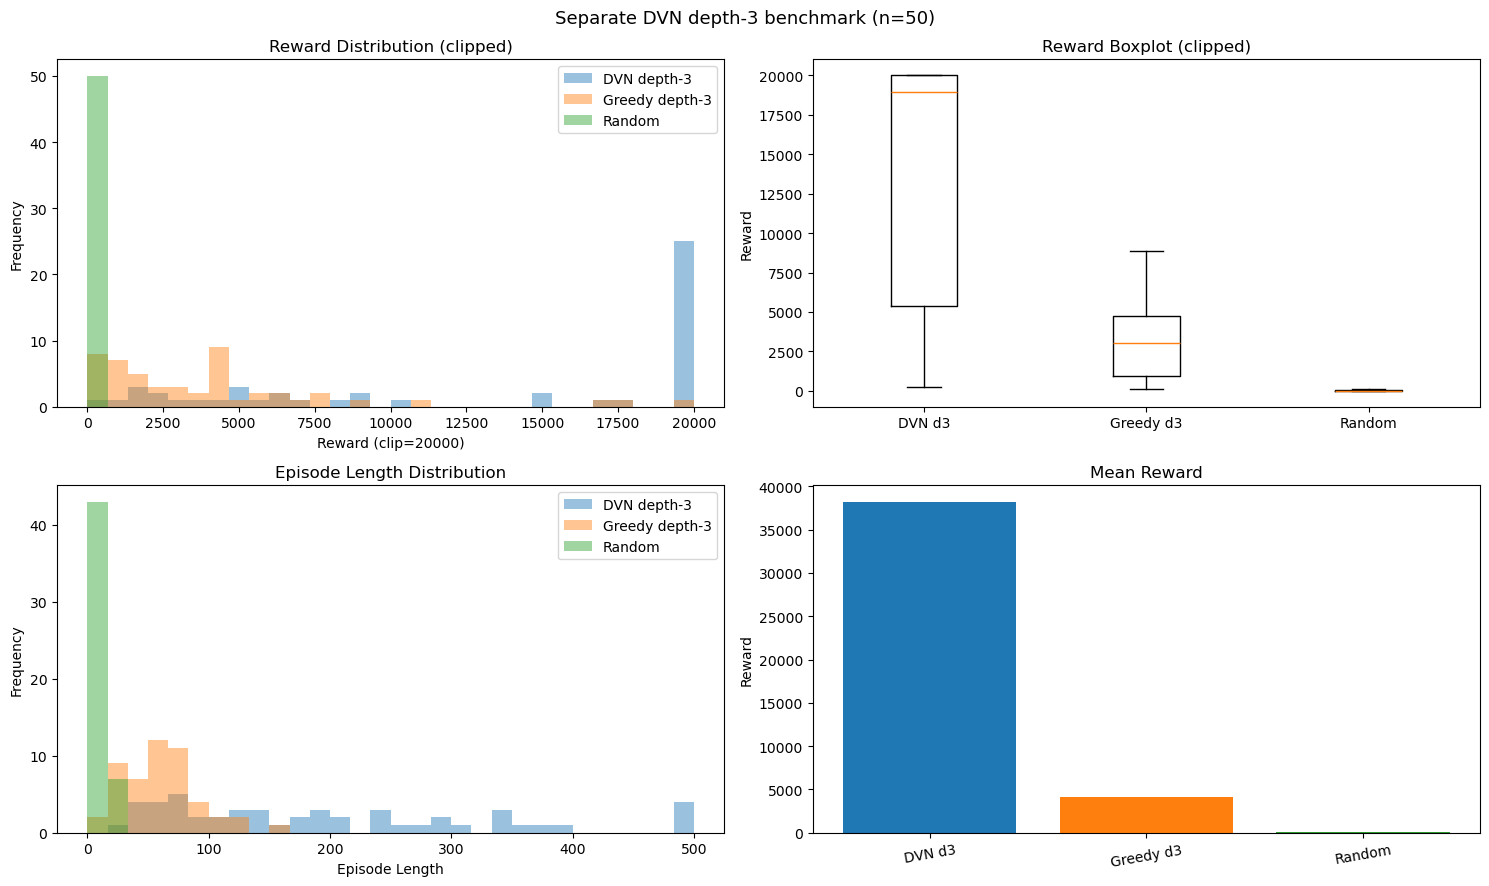

In [40]:
# ── Visualisation benchmark separe DVN depth-3 ──────────────────────
%matplotlib inline

sep_cap = 20000

dvn3_sep_plot = np.clip(dvn3_sep_returns, 0, sep_cap)
g3_sep_plot = np.clip(g3_sep_returns, 0, sep_cap)
rnd_sep_plot = np.clip(rnd_sep_returns, 0, sep_cap)

sep_reward_bins = np.linspace(0, sep_cap, 31)
sep_len_max = max(np.max(dvn3_sep_lengths), np.max(g3_sep_lengths), np.max(rnd_sep_lengths))
sep_length_bins = np.linspace(0, sep_len_max, 31)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
ax.hist(dvn3_sep_plot, bins=sep_reward_bins, alpha=0.45, label='DVN depth-3')
ax.hist(g3_sep_plot, bins=sep_reward_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd_sep_plot, bins=sep_reward_bins, alpha=0.45, label='Random')
ax.set_title('Reward Distribution (clipped)')
ax.set_xlabel(f'Reward (clip={sep_cap})')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[0, 1]
ax.boxplot(
    [dvn3_sep_plot, g3_sep_plot, rnd_sep_plot],
    tick_labels=['DVN d3', 'Greedy d3', 'Random'],
    showfliers=False,
)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Reward')

ax = axes[1, 0]
ax.hist(dvn3_sep_lengths, bins=sep_length_bins, alpha=0.45, label='DVN depth-3')
ax.hist(g3_sep_lengths, bins=sep_length_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd_sep_lengths, bins=sep_length_bins, alpha=0.45, label='Random')
ax.set_title('Episode Length Distribution')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1, 1]
sep_means = [
    float(np.mean(dvn3_sep_returns)),
    float(np.mean(g3_sep_returns)),
    float(np.mean(rnd_sep_returns)),
]
sep_labels = ['DVN d3', 'Greedy d3', 'Random']
ax.bar(sep_labels, sep_means, color=['C0', 'C1', 'C2'])
ax.set_title('Mean Reward')
ax.set_ylabel('Reward')
ax.tick_params(axis='x', rotation=10)

plt.suptitle(f'Separate DVN depth-3 benchmark (n={DVN3_EPISODES})', fontsize=13)
plt.tight_layout()

out_dir = src_path / 'plots'
out_dir.mkdir(exist_ok=True)
from datetime import datetime
fig_sep = out_dir / f"benchmark_3p_separate_dvn_depth3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_sep, dpi=150)
print(f'Separate plot saved to {fig_sep}')
print('\nRaw rewards:')
print('DVN depth-3   :', dvn3_sep_returns.tolist())
print('Greedy depth-3:', g3_sep_returns.tolist())
print('Random        :', rnd_sep_returns.tolist())
plt.show()

## Visualisation ajustée: comparaison `DVN depth-2` vs `DVN depth-3`

Objectif: comparer les distributions malgré des tailles d'échantillons différentes.

- ECDF (utilise toutes les données)
- Histogrammes avec taille alignée (`n = n_depth3`) via sous-échantillonnage répété de depth-2
- Moyenne et IC95% bootstrap sur sous-échantillons de taille alignée

In [42]:
# ── Ajusted DVN depth-2 vs depth-3 comparison ───────────────────────
%matplotlib inline

rng_cmp = np.random.default_rng(SEED + 123456)

# Depth-3 source priority: separate benchmark (50 eps), fallback to previous variable
d3 = None
if 'dvn3_sep_returns' in globals():
    d3 = np.asarray(dvn3_sep_returns, dtype=np.float32)
elif 'dvn3_returns' in globals():
    d3 = np.asarray(dvn3_returns, dtype=np.float32)

d2 = np.asarray(globals()['dvn_returns'], dtype=np.float32) if 'dvn_returns' in globals() else None

if d2 is None or d3 is None:
    print('Impossible de tracer la comparaison ajustee: il manque `dvn_returns` (depth-2) ou `dvn3*_returns` (depth-3) en memoire.')
    print('Tu peux injecter un array depth-2 puis relancer cette cellule, sans rerun complet.')
else:
    n2, n3 = len(d2), len(d3)
    n_match = min(n2, n3)
    B = 1000

    # Subsample depth-2 to match depth-3 size, repeated for stable estimate
    d2_sub_means = np.empty(B, dtype=np.float32)
    d2_sub_p95 = np.empty(B, dtype=np.float32)
    for b in range(B):
        idx = rng_cmp.choice(n2, size=n_match, replace=False)
        sample = d2[idx]
        d2_sub_means[b] = float(sample.mean())
        d2_sub_p95[b] = float(np.percentile(sample, 95))

    d3_boot_means = np.empty(B, dtype=np.float32)
    d3_boot_p95 = np.empty(B, dtype=np.float32)
    for b in range(B):
        idx = rng_cmp.choice(n3, size=n_match, replace=True)
        sample = d3[idx]
        d3_boot_means[b] = float(sample.mean())
        d3_boot_p95[b] = float(np.percentile(sample, 95))

    def ecdf(x):
        xs = np.sort(x)
        ys = np.arange(1, len(xs) + 1) / len(xs)
        return xs, ys

    cap = 20000
    bins = np.linspace(0, cap, 31)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # 1) ECDF full data
    ax = axes[0, 0]
    x2, y2 = ecdf(d2)
    x3, y3 = ecdf(d3)
    ax.plot(x2, y2, label=f'DVN d2 (n={n2})', linewidth=2)
    ax.plot(x3, y3, label=f'DVN d3 (n={n3})', linewidth=2)
    ax.set_title('ECDF (all episodes)')
    ax.set_xlabel('Episode reward')
    ax.set_ylabel('Cumulative proportion')
    ax.grid(alpha=0.2)
    ax.legend()

    # 2) Hist overlay with matched sample size
    ax = axes[0, 1]
    idx_once = rng_cmp.choice(n2, size=n_match, replace=False)
    d2_once = np.clip(d2[idx_once], 0, cap)
    d3_once = np.clip(d3[:n_match], 0, cap) if n3 >= n_match else np.clip(d3, 0, cap)
    ax.hist(d2_once, bins=bins, alpha=0.5, label=f'DVN d2 subsample (n={n_match})')
    ax.hist(d3_once, bins=bins, alpha=0.5, label=f'DVN d3 (n={n_match})')
    ax.set_title('Histogram (matched sample size)')
    ax.set_xlabel(f'Reward (clipped at {cap})')
    ax.set_ylabel('Frequency')
    ax.legend()

    # 3) Mean with bootstrap CI
    ax = axes[1, 0]
    mean2 = float(np.mean(d2_sub_means))
    ci2 = np.percentile(d2_sub_means, [2.5, 97.5])
    mean3 = float(np.mean(d3_boot_means))
    ci3 = np.percentile(d3_boot_means, [2.5, 97.5])
    ax.bar(['DVN d2', 'DVN d3'], [mean2, mean3], color=['C0', 'C1'])
    ax.errorbar([0, 1], [mean2, mean3], yerr=[[mean2 - ci2[0], mean3 - ci3[0]], [ci2[1] - mean2, ci3[1] - mean3]], fmt='none', ecolor='black', capsize=6)
    ax.set_title(f'Mean reward (bootstrap CI, n={n_match})')
    ax.set_ylabel('Reward')

    # 4) Tail proxy (95th percentile)
    ax = axes[1, 1]
    p95_2 = float(np.mean(d2_sub_p95))
    p95_3 = float(np.mean(d3_boot_p95))
    ax.bar(['DVN d2', 'DVN d3'], [p95_2, p95_3], color=['C0', 'C1'])
    ax.set_title(f'95th percentile reward (matched n={n_match})')
    ax.set_ylabel('Reward')

    plt.suptitle('Adjusted comparison: DVN depth-2 vs depth-3', fontsize=13)
    plt.tight_layout()

    out_dir = src_path / 'plots'
    out_dir.mkdir(exist_ok=True)
    from datetime import datetime
    fig_adj = out_dir / f"benchmark_3p_adjusted_d2_vs_d3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(fig_adj, dpi=150)
    print(f'Adjusted comparison plot saved to {fig_adj}')
    print(f'd2 n={n2}, d3 n={n3}, matched n={n_match}, bootstrap B={B}')
    plt.show()

Impossible de tracer la comparaison ajustee: il manque `dvn_returns` (depth-2) ou `dvn3*_returns` (depth-3) en memoire.
Tu peux injecter un array depth-2 puis relancer cette cellule, sans rerun complet.
